In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("../data/processed/olist_cleaned.csv")
print("Shape:", df.shape)
print("Loaded successfully")

Shape: (115038, 37)
Loaded successfully


In [6]:
df['is_weekend'] = df['order_day_of_week'].isin(['Saturday', 'Sunday'])

weekday_orders = df[df['is_weekend'] == False].groupby('order_id')['price'].sum()
weekend_orders = df[df['is_weekend'] == True].groupby('order_id')['price'].sum()

print(f"Weekday orders: {len(weekday_orders):,}")
print(f"Weekend orders: {len(weekend_orders):,}")
print(f"Weekday avg order value: R$ {weekday_orders.mean():.2f}")
print(f"Weekend avg order value: R$ {weekend_orders.mean():.2f}")

Weekday orders: 74,288
Weekend orders: 22,190
Weekday avg order value: R$ 143.69
Weekend avg order value: R$ 141.49


In [7]:
t_stat, p_value = stats.ttest_ind(weekday_orders, weekend_orders)

print("Hypothesis Test: Do weekday and weekend order values differ?")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: YES — statistically significant difference")
else:
    print("Result: NO — no statistically significant difference")

Hypothesis Test: Do weekday and weekend order values differ?
T-statistic: 1.2095
P-value: 0.2265
Result: NO — no statistically significant difference


In [8]:
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
df_reviews = df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

correlation = df_reviews['delivery_days'].corr(df_reviews['review_score'])
print(f"Correlation between delivery days and review score: {correlation:.4f}")

Correlation between delivery days and review score: -0.3027


Average review score by delivery speed:
delivery_speed
Fast (0-7d)         4.329352
Normal (8-14d)      4.197561
Slow (15-21d)       4.015814
Very Slow (21d+)    2.978703
Name: review_score, dtype: float64


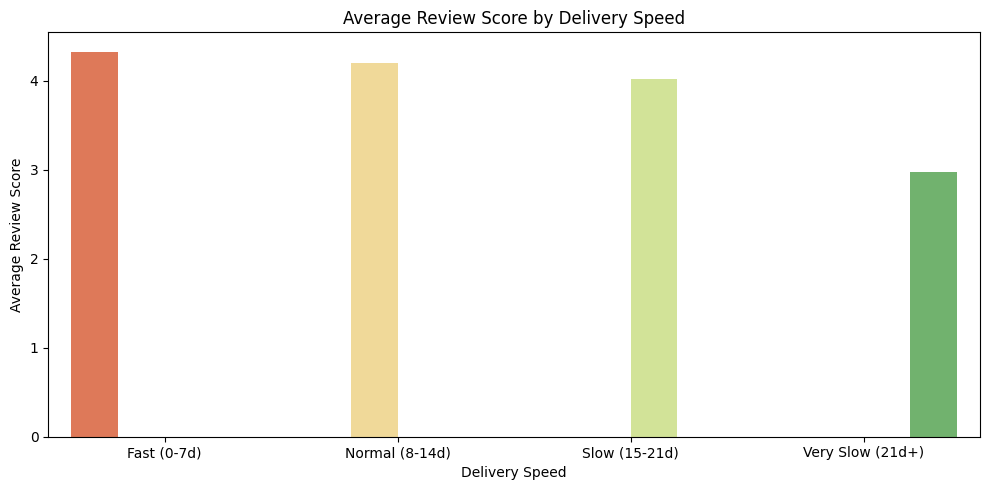

In [9]:
df_reviews['delivery_speed'] = pd.cut(
    df_reviews['delivery_days'],
    bins=[0, 7, 14, 21, 100],
    labels=['Fast (0-7d)', 'Normal (8-14d)', 'Slow (15-21d)', 'Very Slow (21d+)']
)

speed_review = df_reviews.groupby('delivery_speed', observed=True)['review_score'].mean()
print("Average review score by delivery speed:")
print(speed_review)

plt.figure(figsize=(10, 5))
sns.barplot(x=speed_review.index, y=speed_review.values, hue=speed_review.index, palette='RdYlGn', legend=False)
plt.title("Average Review Score by Delivery Speed")
plt.xlabel("Delivery Speed")
plt.ylabel("Average Review Score")
plt.tight_layout()
plt.savefig("../reports/review_by_delivery.png")
plt.show()

Orders by payment type:
  payment_type  order_count
1  credit_card        74304
0       boleto        19191
3      voucher         3679
2   debit_card         1485


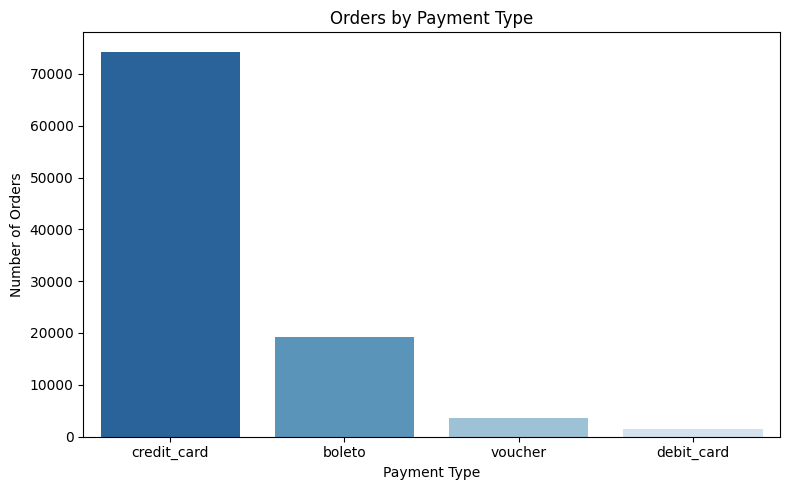

In [10]:
payment_counts = df.groupby('payment_type')['order_id'].nunique().reset_index()
payment_counts.columns = ['payment_type', 'order_count']
payment_counts = payment_counts.sort_values('order_count', ascending=False)

print("Orders by payment type:")
print(payment_counts)

plt.figure(figsize=(8, 5))
sns.barplot(data=payment_counts, x='payment_type', y='order_count', hue='payment_type', palette='Blues_r', legend=False)
plt.title("Orders by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("../reports/payment_types.png")
plt.show()

In [11]:
state_revenue = df.groupby('customer_state')['price'].mean().reset_index()
state_revenue.columns = ['state', 'avg_revenue']
state_revenue = state_revenue.sort_values('avg_revenue', ascending=False).head(10)

print("Top 10 states by average order value:")
print(state_revenue)

Top 10 states by average order value:
   state  avg_revenue
14    PB   194.293868
1     AL   185.150272
0     AC   180.930426
19    RN   166.889893
20    RO   165.502313
13    PA   165.074000
26    TO   164.768503
3     AP   163.310964
16    PI   162.549060
5     CE   154.717085
